# Least squares, rank, and conditioning

CPU companion; no accelerator is required. TPU execution not validated.

- Fit a linear model with a direct solver and diagnose nonunique or sensitive coefficients.
- Solve a fit you can verify by hand
- Use a solver, not an explicit inverse
- Separate rank from fit quality
- Measure sensitivity rather than guessing

Before training a linear model step by step, can we solve it directly? A tiny least-squares fit gives us a reference answer. Then we will make two features nearly identical and see why a good prediction can hide unreliable coefficients.

## The idea

Least squares finds parameters whose predictions are close to the targets under a squared-error objective. Whether those parameters are uniquely determined and stable is a separate question. Nearly redundant features can make weights sensitive even when predictions look good.

## A good fit can hide uncertain parameters

Suppose two feature columns are identical. A prediction using weights $w_1$ and $w_2$ depends only on their sum. The pairs $(1,2)$ and $(2,1)$ therefore produce identical predictions. A low residual cannot tell us which pair is the intended explanation.

If the columns are almost, rather than exactly, identical, tiny data changes can lead to large changes in the separate weights. This is conditioning: how strongly the solution responds to perturbations. Inspect parameter changes as well as prediction error.

The geometric view projects the target vector onto the space spanned by the columns. A target component outside that space remains as residual even after a correct solve. A residual and an unstable parameter estimate are different problems and call for different diagnostics.

### Pause and reason

What evidence would distinguish an unavoidable residual from a faulty least-squares implementation?

<details><summary>Compare your reasoning</summary>

Compare with an independent solver or known projection, inspect rank, and check the residual's orthogonality to the column space within tolerance. A nonzero residual alone does not imply a bug.

</details>

## Solve a fit you can verify by hand

Take rows $(1,0)$, $(0,1)$, $(1,1)$ and targets $y=(1,2,2)$. These targets cannot all be matched. The best weights are $w=(2/3,5/3)$, with predictions $(2/3,5/3,7/3)$. The residual $r=Xw-y=(-1/3,-1/3,1/3)$ has zero dot product with each column. The mean squared error is $1/9$.

$$
\min_w\|Xw-y\|_2^2,\qquad X^\mathsf{T}(Xw-y)=0
$$

## Use a solver, not an explicit inverse

The orthogonality equation implies $X^\mathsf{T}Xw=X^\mathsf{T}y$. This is useful for reasoning, but forming an inverse is not a good default algorithm. Squaring a full-rank matrix into its Gram matrix squares its condition number in the Euclidean norm. Use `jnp.linalg.lstsq` for the direct reference; it also reports numerical rank and singular values. We recompute the residual so its meaning is explicit.

## Separate rank from fit quality

Rank counts independent column directions. If both columns are the same vector $a$, then predictions depend only on $w_0+w_1$. Infinitely many weight pairs give the same prediction. The least-squares solver chooses a minimum-length solution; that convention does not establish which feature caused the target. A zero residual is therefore not evidence that the individual coefficients are identifiable.

## Measure sensitivity rather than guessing

Singular values measure how strongly a matrix stretches different unit directions. For a full-column-rank matrix, the ratio $\kappa=\sigma_{\max}/\sigma_{\min}$ is its condition number. A tiny smallest singular value means some weight changes barely affect predictions. The inverse question—recovering weights from targets—can then amplify small disturbances. Our perturbation experiment is deliberately aligned with such a weak direction. It illustrates sensitivity, not a universal noise model. Rank decisions also depend on the solver cutoff and dtype.

$$
\kappa_2(X)=\frac{\sigma_{\max}(X)}{\sigma_{\min}(X)}
$$

## Construct an imperfect fit

Create main.py and add this small matrix and target. Work out the proposed weights on paper.

In [1]:
# Step 1 — Construct an imperfect fit: No weights can match all three targets, so a nonzero residual is...
# Import jax.numpy for this computation.
import jax.numpy as jnp
import numpy as np
# Initialize array `X` with explicit values and shape.
X = jnp.array([[1.0, 0.0], [0.0, 1.0], [1.0, 1.0]])
# Initialize array `y` with explicit values and shape.
y = jnp.array([1.0, 2.0, 2.0])
# Initialize array `expected` with explicit values and shape.
expected = jnp.array([2 / 3, 5 / 3])

No weights can match all three targets, so a nonzero residual is expected.

## Solve and inspect the residual

Append the direct solve and compute the error from the actual predictions.

In [2]:
# Step 2 — Solve and inspect the residual: Perpendicular residuals verify optimality for this unconstrained...
w, _, rank, singular = jnp.linalg.lstsq(X, y, rcond=None)
# Perform matrix contraction / projection to compute `r`.
r = X @ w - y
# Verify contract: `int(rank) == 2`.
assert int(rank) == 2
# Verify that the output satisfies the expected shape, finite-value, or numerical contract.
assert jnp.allclose(w, expected, atol=2e-06)
# Verify that the output satisfies the expected shape, finite-value, or numerical contract.
assert jnp.allclose(X.T @ r, jnp.zeros(2), atol=2e-06)

Perpendicular residuals verify optimality for this unconstrained least-squares problem.

## Compare independent references

Append the mean loss and a NumPy float64 solve; run python main.py.

In [3]:
# Step 3 — Compare independent references: The hand result and a separate numerical implementation agree...
# Verify that the numerical values match the expected reference within tolerance.
assert jnp.allclose(jnp.mean(r * r), 1 / 9, atol=2e-06)
# Convert `np_w` to a host NumPy array for inspection or verification.
np_w = np.linalg.lstsq(np.asarray(X, dtype=np.float64), np.asarray(y, dtype=np.float64), rcond=None)[0]
# Verify that the numerical values match the expected reference within tolerance.
assert np.allclose(np.asarray(w), np_w, atol=2e-06)
# Print the observed values to compare against the expected result.
print('weights / rank / MSE:', w, rank, jnp.mean(r * r))

weights / rank / MSE: [0.6666669 1.6666665] 2 0.11111113


The hand result and a separate numerical implementation agree within float32 tolerance.

## Run the example

In [4]:
# Step 1 — Construct an imperfect fit: No weights can match all three targets, so a nonzero residual is...
# Import jax.numpy for this computation.
import jax.numpy as jnp
import numpy as np
# Initialize array `X` with explicit values and shape.
X = jnp.array([[1.0, 0.0], [0.0, 1.0], [1.0, 1.0]])
# Initialize array `y` with explicit values and shape.
y = jnp.array([1.0, 2.0, 2.0])
# Initialize array `expected` with explicit values and shape.
expected = jnp.array([2 / 3, 5 / 3])

# Step 2 — Solve and inspect the residual: Perpendicular residuals verify optimality for this unconstrained...
w, _, rank, singular = jnp.linalg.lstsq(X, y, rcond=None)
# Perform matrix contraction / projection to compute `r`.
r = X @ w - y
# Verify contract: `int(rank) == 2`.
assert int(rank) == 2
# Verify that the output satisfies the expected shape, finite-value, or numerical contract.
assert jnp.allclose(w, expected, atol=2e-06)
# Verify that the output satisfies the expected shape, finite-value, or numerical contract.
assert jnp.allclose(X.T @ r, jnp.zeros(2), atol=2e-06)

# Step 3 — Compare independent references: The hand result and a separate numerical implementation agree...
# Verify that the numerical values match the expected reference within tolerance.
assert jnp.allclose(jnp.mean(r * r), 1 / 9, atol=2e-06)
# Convert `np_w` to a host NumPy array for inspection or verification.
np_w = np.linalg.lstsq(np.asarray(X, dtype=np.float64), np.asarray(y, dtype=np.float64), rcond=None)[0]
# Verify that the numerical values match the expected reference within tolerance.
assert np.allclose(np.asarray(w), np_w, atol=2e-06)
# Print the observed values to compare against the expected result.
print('weights / rank / MSE:', w, rank, jnp.mean(r * r))

weights / rank / MSE: [0.6666669 1.6666665] 2 0.11111113


Expected: Weights near $(2/3,5/3)$, rank $2$, mean squared error near $1/9$.

## Least squares balances unavoidable residuals

Predict: Can every target be matched at the same time?

CPU computation; rerun to recompute the data.

Run the cells below to produce the figure, then follow the walkthrough beneath it.

In [5]:
# Compute figure data for: Least squares balances unavoidable residuals
# Perform matrix contraction / projection to compute `visual_data`.
visual_data = {'kind': 'bar', 'labels': ['row 0', 'row 1', 'row 2'], 'ylabel': 'target / prediction', 'series': [{'label': 'target', 'y': y.tolist()}, {'label': 'least-squares fit', 'y': (X @ w).tolist()}]}

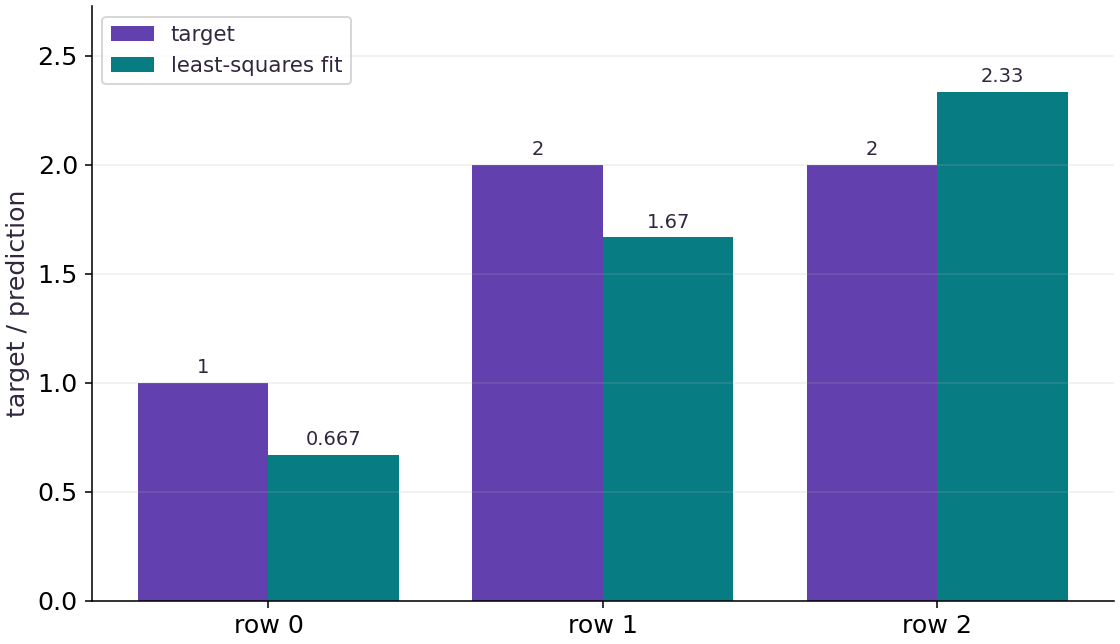

In [6]:
# Render the figure from the data computed above. Change the data experiment and rerun.
import matplotlib.pyplot as plt
plt.rcParams.update({'font.family': 'DejaVu Sans', 'font.size': 13, 'axes.labelcolor': '#30273e', 'text.color': '#30273e'})
def draw_panel(ax, data):
    import numpy as np
    palette = ['#6240ad', '#087c83', '#bc532c', '#405d9d']
    kind = data['kind']
    if kind in ('heatmap', 'field'):
        a = np.asarray(data['values'], dtype=float)
        assert a.ndim == 2 and np.isfinite(a).all()
        kw = {'cmap': 'PuOr' if data.get('diverging') else 'Purples', 'aspect': 'auto'}
        if kind == 'field':
            kw.update(extent=data['extent'], origin='lower', vmin=0, vmax=1)
        elif data.get('diverging'):
            limit = max(float(np.abs(a).max()), 1e-10)
            kw.update(vmin=-limit, vmax=limit)
        if data.get('scale') == 'probability' or data['unit'] in ('attention weight', 'next-token probability', 'masked-token probability'):
            kw.update(vmin=0, vmax=1)
        categorical = data.get('scale') == 'categorical' or any(name in data['unit'] for name in ('device ID','program ID'))
        if categorical:
            from matplotlib.colors import ListedColormap, BoundaryNorm
            from matplotlib import colormaps
            ids=np.unique(a).astype(int)
            boundaries=np.r_[ids[0]-.5,(ids[:-1]+ids[1:])/2,ids[-1]+.5]
            kw.update(cmap=ListedColormap([colormaps['tab20'](i) for i in range(len(ids))]), norm=BoundaryNorm(boundaries,len(ids)))
        im = ax.imshow(a, **kw)
        ax.figure.colorbar(im, ax=ax, shrink=0.8, label=data['unit'], **({'ticks':ids} if categorical else {}))
        if kind == 'heatmap':
            if a.size <= 32:
                mid = (float(a.min()) + float(a.max())) / 2
                for (i, j), value in np.ndenumerate(a):
                    rgb=im.cmap(im.norm(value))[:3]
                    luminance=sum(c*w for c,w in zip(rgb,[0.2126,0.7152,0.0722]))
                    ax.text(j, i, f'{value:.3g}', ha='center', va='center', fontsize=11,
                            color='white' if luminance < 0.5 else '#20202c')
            ax.set_xticks(range(a.shape[1]), data.get('columns', [str(i) for i in range(a.shape[1])]))
            ax.set_yticks(range(a.shape[0]), data.get('rows', [str(i) for i in range(a.shape[0])]))
            if a.shape[1] > 5: ax.tick_params(axis='x', labelsize=11)
        else:
            pts = np.asarray(data['points']); labels = np.asarray(data['labels'])
            for label, marker in [(0, 'o'), (1, '^')]:
                selected = pts[labels == label]
                ax.scatter(selected[:, 0], selected[:, 1], label=f'observed label {label}', marker=marker,
                           s=38, facecolors='white' if label == 0 else '#f4b547', edgecolors='#272238', linewidths=1)
            ax.legend(loc='upper left', fontsize=10)
    elif kind in ('line', 'bar'):
        series = data['series']
        x = np.asarray(data.get('x', list(range(len(data.get('labels', []))))))
        assert len(x) and np.isfinite(x).all()
        for i, s in enumerate(series):
            y = np.asarray(s['y'], dtype=float)
            assert y.shape == x.shape and np.isfinite(y).all(), s['label']
            if data.get('yscale') == 'log': assert (y > 0).all()
            if kind == 'line':
                ax.plot(x, y, color=palette[i % len(palette)], label=s['label'], linewidth=2.3,
                        linestyle=['-', '--', '-.', ':'][i % 4], marker='o' if len(x) <= 25 else None, markersize=3)
            else:
                width = 0.78 / len(series)
                bars = ax.bar(x + (i - (len(series)-1)/2)*width, y, width, label=s['label'], color=palette[i % len(palette)])
                if len(x)*len(series) <= 12: ax.bar_label(bars, fmt='%.3g', fontsize=10, padding=3)
        if kind == 'bar':
            ax.set_xticks(x, data['labels'])
            ax.margins(y=0.17)
            if any(len(t) > 13 for t in data['labels']): ax.tick_params(axis='x', labelrotation=15, labelsize=11)
        if data.get('xscale'): ax.set_xscale(data['xscale'])
        if data.get('yscale'): ax.set_yscale(data['yscale'], **({'linthresh':data.get('linthresh',2)} if data['yscale']=='symlog' else {}))
        for marker in data.get('markers',[]):
            ax.scatter([marker['x']],[marker['y']],color='#bc532c',s=45,zorder=5)
            ax.annotate(marker['label'],(marker['x'],marker['y']),xytext=(-85,12),textcoords='offset points',fontsize=10)
        for boundary in data.get('boundaries', []): ax.axvline(boundary, color='#716e7b', linestyle=':', linewidth=1)
        ax.grid(axis='y', alpha=0.2)
        ax.legend(fontsize=11, loc='best')
    elif kind == 'vectors':
        for i, arrow in enumerate(data['arrows']):
            start = np.asarray(arrow['start']); end = np.asarray(arrow['end'])
            ax.annotate('', xy=end, xytext=start, arrowprops={'arrowstyle':'->','color':palette[i], 'lw':2.8})
            mid=(start+end)/2
            ax.annotate(arrow['label'], mid, xytext=(7,7), textcoords='offset points', color=palette[i])
        ax.set(xlim=(-0.7,4.5),ylim=(-0.7,5),xlabel='first coordinate',ylabel='second coordinate')
        ax.set_aspect('equal'); ax.grid(alpha=0.2)
    elif kind == 'flow':
        from matplotlib.patches import FancyBboxPatch
        nodes=data['nodes']; ax.set(xlim=(0,1),ylim=(0,len(nodes))); ax.axis('off')
        if data.get('layout') == 'merge':
            import textwrap
            for i,label in enumerate(nodes[:3]):
                x=0.02+i*0.33
                ax.add_patch(FancyBboxPatch((x,3.7),0.29,1.0,boxstyle='round,pad=0.015',facecolor='#f0eafa',edgecolor='#6240ad'))
                ax.text(x+0.145,4.2,textwrap.fill(label,20),ha='center',va='center',fontsize=11)
                ax.annotate('',(0.5,2.8),(x+0.145,3.67),arrowprops={'arrowstyle':'->','color':'#6240ad'})
            for y,label in [(2.4,nodes[3]),(0.9,nodes[4])]:
                ax.add_patch(FancyBboxPatch((0.08,y-0.35),0.84,0.7,boxstyle='round,pad=0.025',facecolor='#f0eafa',edgecolor='#6240ad'))
                ax.text(0.5,y,label,ha='center',va='center',fontsize=12)
            ax.annotate('',(0.5,1.3),(0.5,2.0),arrowprops={'arrowstyle':'->','color':'#6240ad'})
        else:
            for i, label in enumerate(nodes):
                y=len(nodes)-i-0.5
                ax.add_patch(FancyBboxPatch((0.08,y-0.3),0.84,0.6,boxstyle='round,pad=0.025',facecolor='#f0eafa',edgecolor='#6240ad'))
                ax.text(0.5,y,label,ha='center',va='center',fontsize=12)
                if i<len(nodes)-1: ax.annotate('',(0.5,y-0.67),(0.5,y-0.32),arrowprops={'arrowstyle':'->','color':'#6240ad'})
    else: raise ValueError(f'Unknown figure kind: {kind}')
    if data.get('xlabel'): ax.set_xlabel(data['xlabel'])
    if data.get('ylabel'): ax.set_ylabel(data['ylabel'])
    if data.get('title'): ax.set_title(data['title'], loc='left', fontsize=12, pad=12)
    for spine in ('top','right'): ax.spines[spine].set_visible(False)


def draw_mechanism(ax, diagram):
    """Draw a source-authored conceptual/analytic mechanism, never measured data."""
    import numpy as np
    from matplotlib.patches import FancyBboxPatch, Rectangle, Circle, Ellipse
    panel = diagram['panel']
    kind = panel['kind']
    colors = {'data':('#eef3ff','#3559a8'), 'state':('#f0eafa','#6240ad'),
              'fixed':('#f1f3f5','#536273'), 'result':('#e5f4ee','#17735c'),
              'warning':('#fff0e6','#a64d20')}
    if kind == 'graph':
        ax.set(xlim=(0,panel.get('width',10)),ylim=(panel.get('height',8),0))
        ax.axis('off')
        nodes={node['id']:node for node in panel['nodes']}
        for edge in panel['edges']:
            a,b=nodes[edge['from']],nodes[edge['to']]
            side_a=edge.get('exit','bottom'); side_b=edge.get('enter','top')
            def port(node,side):
                x,y=node['x'],node['y']; w,h=node.get('w',3),node.get('h',.8)
                return {'top':(x,y-h/2),'bottom':(x,y+h/2),'left':(x-w/2,y),'right':(x+w/2,y)}[side]
            start,end=port(a,side_a),port(b,side_b)
            ax.annotate('',xy=end,xytext=start,arrowprops={'arrowstyle':'-|>','color':'#536273','lw':1.7,'connectionstyle':edge.get('curve','arc3,rad=0')},zorder=1)
            if edge.get('label'):
                tx,ty=edge.get('labelAt',((start[0]+end[0])/2,(start[1]+end[1])/2))
                ax.text(tx,ty,edge['label'],ha='center',va='center',fontsize=10,color='#394658',bbox={'facecolor':'white','edgecolor':'none','pad':2},zorder=4)
        for node in panel['nodes']:
            fill,stroke=colors[node.get('tone','data')]
            x,y=node['x'],node['y'];w,h=node.get('w',3),node.get('h',.8)
            ax.add_patch(FancyBboxPatch((x-w/2,y-h/2),w,h,boxstyle='round,pad=0.02,rounding_size=0.07',facecolor=fill,edgecolor=stroke,lw=1.5,zorder=2))
            ax.text(x,y,node['label'],ha='center',va='center',fontsize=node.get('fontSize',12),color='#172334',zorder=3)
    elif kind == 'table':
        ax.axis('off')
        table=ax.table(cellText=panel['rows'],colLabels=panel['headers'],cellLoc='center',loc='center',colWidths=panel.get('widths'))
        table.auto_set_font_size(False);table.set_fontsize(12);table.scale(1,2.7)
        for (row,col),cell in table.get_celld().items():
            cell.set_edgecolor('#ccd3df')
            cell.set_facecolor('#e9e4f5' if row==0 else ('#f4f7fb' if row%2 else '#ffffff'))
            cell.set_text_props(color='#172334',weight='bold' if row==0 else 'normal')
    elif kind == 'clipping':
        ax.add_patch(Circle((0,0),2.5,fill=False,edgecolor='#17735c',linestyle='--',lw=1.8))
        ax.add_patch(Rectangle((-2.5,-2.5),5,5,fill=False,edgecolor='#a64d20',linestyle=':',lw=1.8))
        for end,color,label,offset in [((3,4),'#3559a8','Original (3, 4)',(8,5)),((1.5,2),'#17735c','Norm clip (1.5, 2)',(-126,-16)),((2.5,2.5),'#a64d20','Coordinate clip (2.5, 2.5)',(8,-2))]:
            ax.annotate('',xy=end,xytext=(0,0),arrowprops={'arrowstyle':'-|>','color':color,'lw':2.6})
            ax.annotate(label,end,xytext=offset,textcoords='offset points',color=color,fontsize=11)
        ax.set(xlim=(-3,5.8),ylim=(-3,4.8),xlabel='gradient coordinate 1',ylabel='gradient coordinate 2')
        ax.set_aspect('equal');ax.grid(alpha=.15)
    elif kind == 'patches':
        ax.set(xlim=(-.1,4.1),ylim=(4.1,-.1));ax.set_aspect('equal');ax.axis('off')
        for i in range(4):
            x,y=(i%2)*2,(i//2)*2
            visible=i in [0,3]
            ax.add_patch(Rectangle((x,y),2,2,facecolor='#e5f4ee' if visible else '#fff0e6',edgecolor='#17735c' if visible else '#a64d20',hatch=None if visible else '///',lw=2))
            ax.text(x+1,y+1,f'Patch {i}\n'+('visible input' if visible else 'hidden target'),ha='center',va='center',fontsize=14,bbox={'facecolor':'white','edgecolor':'none','alpha':.94,'pad':5})
        for a in [1,3]:
            ax.axhline(a,color='#172334',alpha=.25,lw=.7);ax.axvline(a,color='#172334',alpha=.25,lw=.7)
    elif kind == 'receptive-field':
        ax.set(xlim=(-.15,5.15),ylim=(5.15,-.15));ax.set_aspect('equal');ax.axis('off')
        for row in range(5):
            for col in range(5):
                selected=1<=row<=3 and 1<=col<=3
                ax.add_patch(Rectangle((col,row),1,1,facecolor='#e9e4f5' if selected else '#f4f7fb',edgecolor='#a6afc1',lw=1))
                ax.text(col+.5,row+.5,f'{row},{col}',ha='center',va='center',fontsize=12)
        ax.add_patch(Rectangle((1,1),3,3,fill=False,edgecolor='#6240ad',lw=3))
        ax.set_title('One 3 × 3 receptive field inside a 5 × 5 input',fontsize=13,pad=12)
    elif kind == 'covariance':
        for covariance,color,label in [(np.array([[1,.8],[.8,1]]),'#6240ad','Correlated covariance'),(np.eye(2),'#17735c','Same marginals, zero covariance')]:
            eig,vec=np.linalg.eigh(covariance);order=np.argsort(eig)[::-1];eig=eig[order];vec=vec[:,order]
            angle=np.degrees(np.arctan2(vec[1,0],vec[0,0]))
            ax.add_patch(Ellipse((0,0),2*np.sqrt(eig[0]),2*np.sqrt(eig[1]),angle=angle,fill=False,lw=2.5,edgecolor=color,label=label))
        ax.set(xlim=(-1.8,1.8),ylim=(-1.8,1.8),xlabel='first variable',ylabel='second variable')
        ax.set_aspect('equal');ax.grid(alpha=.2);ax.legend(loc='upper center',bbox_to_anchor=(.5,-.14),fontsize=10)
    elif kind == 'timeline':
        ax.set(xlim=(0,10),ylim=(-.7,2.7),yticks=[0,1,2],yticklabels=['Host','Device','Measurement'])
        for start,length,y,label,color in [(0,1,0,'dispatch','#3559a8'),(1,6,1,'device work','#6240ad'),(1,6,0,'wait for result','#a64d20'),(0,7,2,'completed-result interval','#17735c')]:
            ax.barh(y,length,left=start,height=.45,color=color,alpha=.18)
            ax.text(start+length/2,y,label,ha='center',va='center',fontsize=11)
        ax.axvline(7,color='#536273',linestyle='--');ax.text(7.1,.5,'result ready',fontsize=11)
        ax.set_xlabel('conceptual order; lengths are not measured durations')
        ax.invert_yaxis()
    else:
        raise ValueError(f'Unknown mechanism kind: {kind}')

panels = visual_data.get('panels', [visual_data])
fig, axes = plt.subplots(len(panels), 1, figsize=(8, 4.6 * len(panels)), squeeze=False, layout='constrained')
for ax, panel in zip(axes[:, 0], panels):
    draw_panel(ax, panel)
plt.show()

### Read the figure

For each observation, compare the target bar with the least-squares prediction beside it. Targets are $(1,2,2)$; predictions are approximately $(0.667,1.667,2.333)$. The fitted model falls short on the first two rows and exceeds the target on the third.

Each vertical gap has magnitude $1/3$, but the signs differ. Using prediction minus target, the residual vector is $(-1/3,-1/3,1/3)$. The mean squared error is therefore $1/9$, despite no bar pair matching exactly.

### Connect it to the computation

The feature matrix makes the third prediction equal the sum of the first two. Matching the first two targets exactly would force the third prediction to be $3$, not its target $2$. An exact fit is impossible with these features.

Least squares balances this conflict. For each feature column, the residual contributions cancel, giving $X^{\mathsf T}r=0$. That orthogonality, rather than zero residual on every row, is the optimality condition. The unequal bar heights are an unavoidable limitation of this model, not evidence that the solver failed.

## Duplicate a feature

Predict: For identical columns, can we tell whether a coefficient belongs to the first or second column?

In [7]:
# Experiment — Duplicate a feature: Fit quality and coefficient uniqueness are different questions.
# Initialize array `a` with explicit values and shape.
a = jnp.array([1.0, 2.0, 3.0])
# Combine or mask array elements to form `duplicate`.
duplicate = jnp.stack([a, a], axis=1)
# Run `jnp.linalg.lstsq` to compute `(w_dup, _, rank_dup, _)`.
w_dup, _, rank_dup, _ = jnp.linalg.lstsq(duplicate, 3 * a, rcond=None)
# Verify contract: `int(rank_dup) == 1`.
assert int(rank_dup) == 1
# Verify that the output satisfies the expected shape, finite-value, or numerical contract.
assert jnp.allclose(duplicate @ w_dup, 3 * a, atol=3e-06)
# Verify that the output satisfies the expected shape, finite-value, or numerical contract.
assert jnp.allclose(duplicate @ jnp.array([1.0, 2.0]), duplicate @ jnp.array([0.0, 3.0]))

Expected: Rank $1$; different weight pairs make identical predictions.

Fit quality and coefficient uniqueness are different questions.

## Perturb a weak direction

Predict: If two columns differ by only $0.01$ in one row, can a target change of $0.001$ move a weight by much more?

In [8]:
# Experiment — Perturb a weak direction: Nearly dependent columns can amplify target perturbations while...
# Initialize array `near` with explicit values and shape.
near = jnp.array([[1.0, 1.0], [0.0, 0.01], [0.0, 0.0]])
# Initialize array `base` with explicit values and shape.
base = near @ jnp.array([1.0, 1.0])
# Initialize array `changed` with explicit values and shape.
changed = base + jnp.array([0.0, 0.001, 0.0])
# Run `jnp.linalg.lstsq` to compute `w0`.
w0 = jnp.linalg.lstsq(near, base, rcond=None)[0]
# Run `jnp.linalg.lstsq` to compute `w1`.
w1 = jnp.linalg.lstsq(near, changed, rcond=None)[0]
# Verify that the numerical values match the expected reference within tolerance.
assert jnp.allclose(w1 - w0, jnp.array([-0.1, 0.1]), atol=5e-05)
# Print the observed values to compare against the expected result.
print('condition / target change / weight change:', jnp.linalg.cond(near), jnp.linalg.norm(changed - base), jnp.linalg.norm(w1 - w0))

condition / target change / weight change: 200.00504 0.0010000002 0.14142144


Expected: The target change has length $0.001$, but the weight change has length about $0.1414$.

Nearly dependent columns can amplify target perturbations while preserving a close prediction fit.

## Your exercise

Add a constant bias column to inputs $(-1,0,1)$ and fit targets $(-1,1,3)$. Recover slope $2$ and bias $1$.

### How to write this exercise — Step-by-step recipe & starter scaffold

**Key functions & syntax to use:**
- `jnp.array(values, dtype=...)` — Constructs an immutable device-backed JAX array from Python/NumPy values.
- `jnp.allclose(actual, expected, rtol=..., atol=...)` — Checks that two arrays match elementwise within floating-point tolerance.

**Step-by-step implementation plan:**
1. Initialize array `x` with explicit values and shape.
2. Initialize array `design` with explicit values and shape.
3. Run `jnp.linalg.lstsq` to compute `fit`.
4. Verify that the numerical values match the expected reference within tolerance.

**Starter code scaffold (fill in the TODOs):**

```python
# Exercise solution: Add a constant bias column to inputs (-1,0,1) and fit targets (-1,1,3).
# Initialize array `x` with explicit values and shape.
x = jnp.array(...)  # TODO: compute x
# Initialize array `design` with explicit values and shape.
design = jnp.stack(...)  # TODO: compute design
# Run `jnp.linalg.lstsq` to compute `fit`.
fit = jnp.linalg.lstsq(...)  # TODO: compute fit
# Verify that the numerical values match the expected reference within tolerance.
assert jnp.allclose(fit, jnp.array([2.0, 1.0]), atol=2e-06)  # TODO: complete assertion check
```

In [9]:
# Write your attempt here (uncomment and fill in the TODOs below):
# Exercise solution: Add a constant bias column to inputs (-1,0,1) and fit targets (-1,1,3).
# Initialize array `x` with explicit values and shape.
# x = jnp.array(...)  # TODO: compute x
# Initialize array `design` with explicit values and shape.
# design = jnp.stack(...)  # TODO: compute design
# Run `jnp.linalg.lstsq` to compute `fit`.
# fit = jnp.linalg.lstsq(...)  # TODO: compute fit
# Verify that the numerical values match the expected reference within tolerance.
# assert jnp.allclose(fit, jnp.array([2.0, 1.0]), atol=2e-06)  # TODO: complete assertion check

## Reference solution

Try your own implementation first.

In [10]:
# Exercise solution: Add a constant bias column to inputs (-1,0,1) and fit targets (-1,1,3).
# Initialize array `x` with explicit values and shape.
x = jnp.array([-1.0, 0.0, 1.0])
# Initialize array `design` with explicit values and shape.
design = jnp.stack([x, jnp.ones_like(x)], axis=1)
# Run `jnp.linalg.lstsq` to compute `fit`.
fit = jnp.linalg.lstsq(design, 2 * x + 1, rcond=None)[0]
# Verify that the numerical values match the expected reference within tolerance.
assert jnp.allclose(fit, jnp.array([2.0, 1.0]), atol=2e-06)

## Change feature units · Transfer / diagnosis

Multiply the first feature of $X$ by $100$. Predict the new weights and compare predictions.

Hint: The first weight must divide by $100$ to represent the same model.

### How to write: Change feature units — Step-by-step recipe & starter scaffold

**Key functions & syntax to use:**
- `jnp.array(values, dtype=...)` — Constructs an immutable device-backed JAX array from Python/NumPy values.
- `jnp.allclose(actual, expected, rtol=..., atol=...)` — Checks that two arrays match elementwise within floating-point tolerance.

**Step-by-step implementation plan:**
1. Initialize array `scaled` with explicit values and shape.
2. Run `jnp.linalg.lstsq` to compute `ws`.
3. Verify that the numerical values match the expected reference within tolerance.
4. Verify that the output satisfies the expected shape, finite-value, or numerical contract.

**Starter code scaffold (fill in the TODOs):**

```python
# Change feature units (Transfer / diagnosis): Feature units affect coefficients and conditioning.
# Initialize array `scaled` with explicit values and shape.
scaled = ...  # TODO: compute scaled
# Run `jnp.linalg.lstsq` to compute `ws`.
ws = jnp.linalg.lstsq(...)  # TODO: compute ws
# Verify that the numerical values match the expected reference within tolerance.
assert jnp.allclose(ws, expected / jnp.array([100.0, 1.0]), atol=3e-06)  # TODO: complete assertion check
# Verify that the output satisfies the expected shape, finite-value, or numerical contract.
assert jnp.allclose(scaled @ ws, X @ w, atol=3e-06)  # TODO: complete assertion check
```

In [11]:
# Write your attempt here (uncomment and fill in the TODOs below):
# Change feature units (Transfer / diagnosis): Feature units affect coefficients and conditioning.
# Initialize array `scaled` with explicit values and shape.
# scaled = ...  # TODO: compute scaled
# Run `jnp.linalg.lstsq` to compute `ws`.
# ws = jnp.linalg.lstsq(...)  # TODO: compute ws
# Verify that the numerical values match the expected reference within tolerance.
# assert jnp.allclose(ws, expected / jnp.array([100.0, 1.0]), atol=3e-06)  # TODO: complete assertion check
# Verify that the output satisfies the expected shape, finite-value, or numerical contract.
# assert jnp.allclose(scaled @ ws, X @ w, atol=3e-06)  # TODO: complete assertion check

## Reference reasoning

Feature units affect coefficients and conditioning. They need not change the fitted prediction space.

In [12]:
# Change feature units (Transfer / diagnosis): Feature units affect coefficients and conditioning.
# Initialize array `scaled` with explicit values and shape.
scaled = X * jnp.array([100.0, 1.0])
# Run `jnp.linalg.lstsq` to compute `ws`.
ws = jnp.linalg.lstsq(scaled, y, rcond=None)[0]
# Verify that the numerical values match the expected reference within tolerance.
assert jnp.allclose(ws, expected / jnp.array([100.0, 1.0]), atol=3e-06)
# Verify that the output satisfies the expected shape, finite-value, or numerical contract.
assert jnp.allclose(scaled @ ws, X @ w, atol=3e-06)

## Explain the squared conditioning · Transfer / diagnosis

Compare the condition numbers of the diagonal matrix with entries $(1,0.1)$ and its Gram matrix. Why is a solver preferable to forming the inverse?

Hint: The diagonal entries are singular values here; squaring them changes the ratio from $10$ to $100$.

### How to write: Explain the squared conditioning — Step-by-step recipe & starter scaffold

**Key functions & syntax to use:**
- `jnp.array(values, dtype=...)` — Constructs an immutable device-backed JAX array from Python/NumPy values.
- `jnp.allclose(actual, expected, rtol=..., atol=...)` — Checks that two arrays match elementwise within floating-point tolerance.

**Step-by-step implementation plan:**
1. Initialize array `D` with explicit values and shape.
2. Verify that the numerical values match the expected reference within tolerance.
3. Verify that the output satisfies the expected shape, finite-value, or numerical contract.

**Starter code scaffold (fill in the TODOs):**

```python
# Explain the squared conditioning (Transfer / diagnosis): The normal equations can worsen numerical sensitivity.
# Initialize array `D` with explicit values and shape.
D = jnp.diag(...)  # TODO: compute D
# Verify that the numerical values match the expected reference within tolerance.
assert jnp.allclose(jnp.linalg.cond(D), 10.0)  # TODO: complete assertion check
# Verify that the output satisfies the expected shape, finite-value, or numerical contract.
assert jnp.allclose(jnp.linalg.cond(D.T @ D), 100.0, rtol=2e-06)  # TODO: complete assertion check
```

In [13]:
# Write your attempt here (uncomment and fill in the TODOs below):
# Explain the squared conditioning (Transfer / diagnosis): The normal equations can worsen numerical sensitivity.
# Initialize array `D` with explicit values and shape.
# D = jnp.diag(...)  # TODO: compute D
# Verify that the numerical values match the expected reference within tolerance.
# assert jnp.allclose(jnp.linalg.cond(D), 10.0)  # TODO: complete assertion check
# Verify that the output satisfies the expected shape, finite-value, or numerical contract.
# assert jnp.allclose(jnp.linalg.cond(D.T @ D), 100.0, rtol=2e-06)  # TODO: complete assertion check

## Reference reasoning

The normal equations can worsen numerical sensitivity. A small residual alone does not certify coefficient accuracy.

In [14]:
# Explain the squared conditioning (Transfer / diagnosis): The normal equations can worsen numerical sensitivity.
# Initialize array `D` with explicit values and shape.
D = jnp.diag(jnp.array([1.0, 0.1]))
# Verify that the numerical values match the expected reference within tolerance.
assert jnp.allclose(jnp.linalg.cond(D), 10.0)
# Verify that the output satisfies the expected shape, finite-value, or numerical contract.
assert jnp.allclose(jnp.linalg.cond(D.T @ D), 100.0, rtol=2e-06)

## Checkpoint

Can zero training error prove that fitted weights are uniquely determined?

1. Yes, zero error is a unique solution
2. No; dependent columns can produce many equally good weights
3. Only if we use float64

## Diagnose

If a fit changes sharply after a small target perturbation, inspect singular values and feature units. If rank drops, inspect duplicate columns and the cutoff. Compare residuals and predictions as well as coefficients.

## Evidence

Save the hand solution, residual orthogonality, duplicate-column ambiguity, perturbation table and NumPy comparison.

## Carry forward

- Fit quality and coefficient uniqueness are different questions.
- Nearly dependent columns can amplify target perturbations while preserving a close prediction fit.

## Primary references

- [JAX least-squares solver](https://docs.jax.dev/en/latest/_autosummary/jax.numpy.linalg.lstsq.html)
- [MIT: positive definite matrices and least squares](https://ocw.mit.edu/courses/18-06-linear-algebra-spring-2010/resources/lecture-16-projection-matrices-and-least-squares/)